# Análise Exploratória de Dados — Retailrocket

Dataset de e-commerce com eventos de comportamento de usuários, propriedades de itens e árvore de categorias.

**Arquivos:**
- `events.csv` — eventos de interação (view, addtocart, transaction)
- `item_properties_part1.csv` + `item_properties_part2.csv` — propriedades dos itens ao longo do tempo
- `category_tree.csv` — hierarquia de categorias

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_DIR = Path("../data/raw")

---
## 1. Carregamento dos dados

In [16]:
events = pd.read_csv(DATA_DIR / "events.csv")
cat_tree = pd.read_csv(DATA_DIR / "category_tree.csv")

props1 = pd.read_csv(DATA_DIR / "item_properties_part1.csv")
props2 = pd.read_csv(DATA_DIR / "item_properties_part2.csv")
props = pd.concat([props1, props2], ignore_index=True)

del props1, props2

print("events:    ", events.shape)
print("cat_tree:  ", cat_tree.shape)
print("props:     ", props.shape)

events:     (2756101, 5)
cat_tree:   (1669, 2)
props:      (20275902, 4)


---
## 2. Events

In [17]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [18]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


In [19]:
print("Nulos por coluna:")
print(events.isnull().sum())
print(
    f"\nTransactionid nulo corresponde a eventos não-transacionais: {events[events.transactionid.isnull()].event.unique()}"
)

Nulos por coluna:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Transactionid nulo corresponde a eventos não-transacionais: <StringArray>
['view', 'addtocart']
Length: 2, dtype: str


In [20]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")

print("Período coberto:")
print(f"  Início: {events.timestamp.min()}")
print(f"  Fim:    {events.timestamp.max()}")
print(f"  Duração: {(events.timestamp.max() - events.timestamp.min()).days} dias")

Período coberto:
  Início: 2015-05-03 03:00:04.384000
  Fim:    2015-09-18 02:59:47.788000
  Duração: 137 dias


### 2.1 Distribuição de tipos de evento

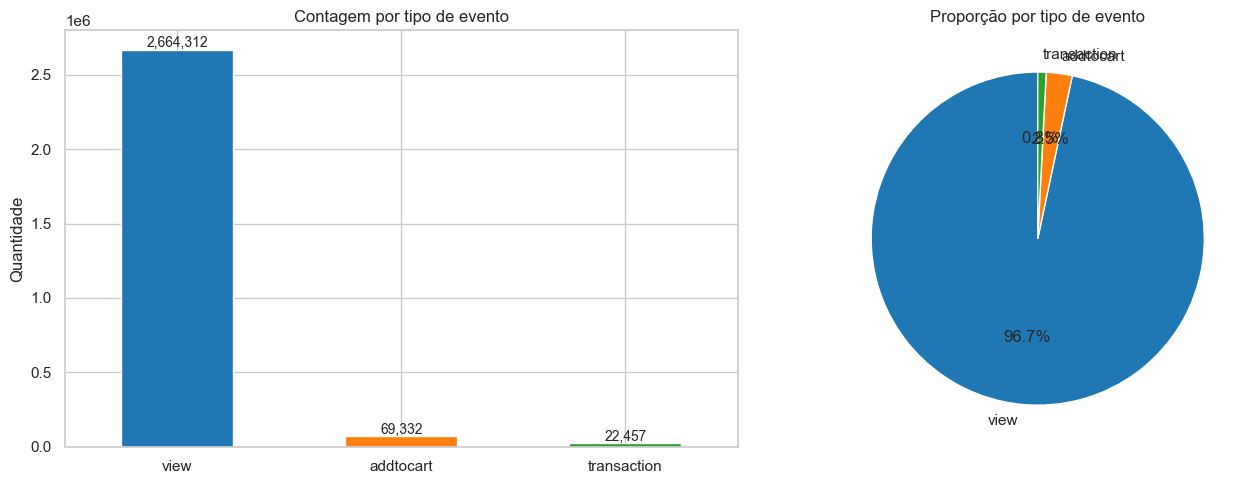

event
view           2664312
addtocart        69332
transaction      22457


In [21]:
event_counts = events["event"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

event_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("tab10", 3))
axes[0].set_title("Contagem por tipo de evento")
axes[0].set_xlabel("")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(
        f"{int(bar.get_height()):,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )

axes[1].pie(
    event_counts,
    labels=event_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("tab10", 3),
    startangle=90,
)
axes[1].set_title("Proporção por tipo de evento")

plt.tight_layout()
plt.show()

print(event_counts.to_string())

### 2.2 Funil de conversão

View → Addtocart:   2.60%
Addtocart → Buy:    32.39%
View → Buy:         0.84%


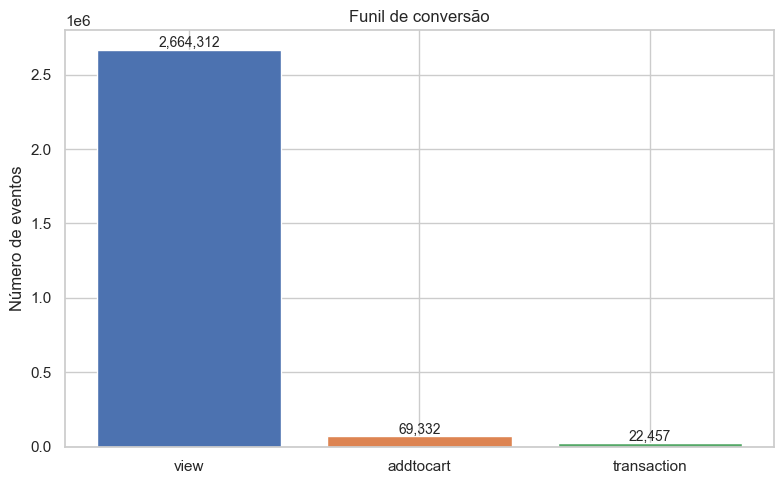

In [22]:
funnel = event_counts.reindex(["view", "addtocart", "transaction"])

view_to_cart = funnel["addtocart"] / funnel["view"] * 100
cart_to_purchase = funnel["transaction"] / funnel["addtocart"] * 100
view_to_purchase = funnel["transaction"] / funnel["view"] * 100

print(f"View → Addtocart:   {view_to_cart:.2f}%")
print(f"Addtocart → Buy:    {cart_to_purchase:.2f}%")
print(f"View → Buy:         {view_to_purchase:.2f}%")

plt.figure(figsize=(8, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = plt.bar(funnel.index, funnel.values, color=colors)
for bar, val in zip(bars, funnel.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.title("Funil de conversão")
plt.ylabel("Número de eventos")
plt.tight_layout()
plt.show()

### 2.3 Visitantes e itens únicos

In [23]:
print(f"Visitantes únicos:         {events.visitorid.nunique():,}")
print(f"Itens únicos:              {events.itemid.nunique():,}")
print(f"Transações únicas:         {events.transactionid.dropna().nunique():,}")

visitor_events = events.groupby("visitorid").size()
print("\nEventos por visitante:")
print(visitor_events.describe().apply(lambda x: f"{x:.2f}"))

Visitantes únicos:         1,407,580
Itens únicos:              235,061
Transações únicas:         17,672

Eventos por visitante:
count    1407580.00
mean           1.96
std           12.58
min            1.00
25%            1.00
50%            1.00
75%            2.00
max         7757.00
dtype: str


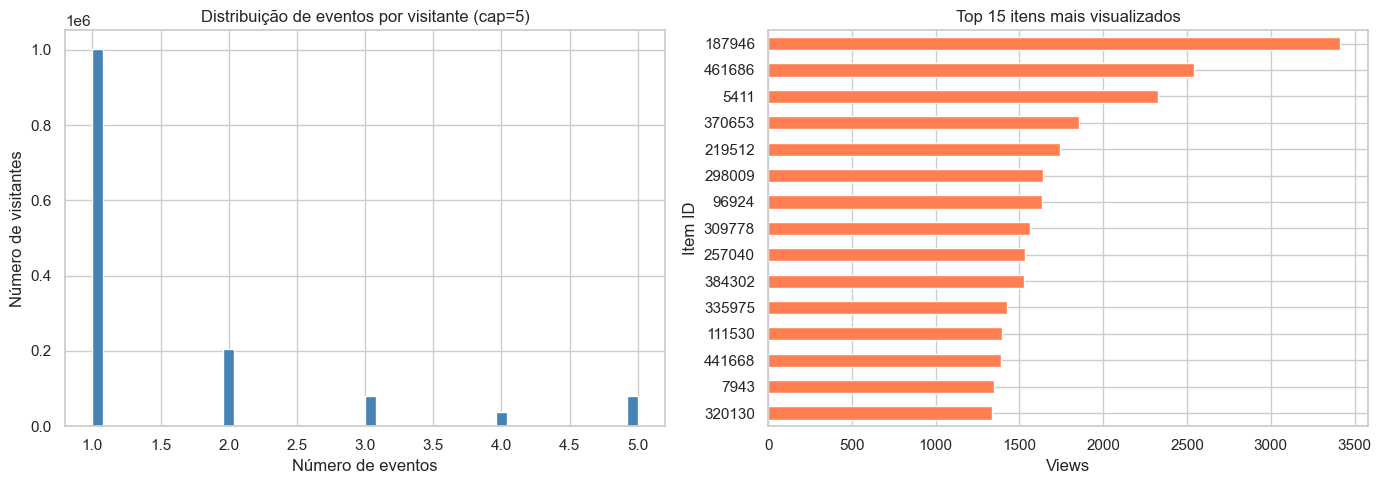

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = int(visitor_events.quantile(0.95))
visitor_events.clip(upper=cap).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title(f"Distribuição de eventos por visitante (cap={cap})")
axes[0].set_xlabel("Número de eventos")
axes[0].set_ylabel("Número de visitantes")

top_items = events[events.event == "view"]["itemid"].value_counts().head(15)
top_items.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 15 itens mais visualizados")
axes[1].set_xlabel("Views")
axes[1].set_ylabel("Item ID")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 2.4 Evolução temporal dos eventos

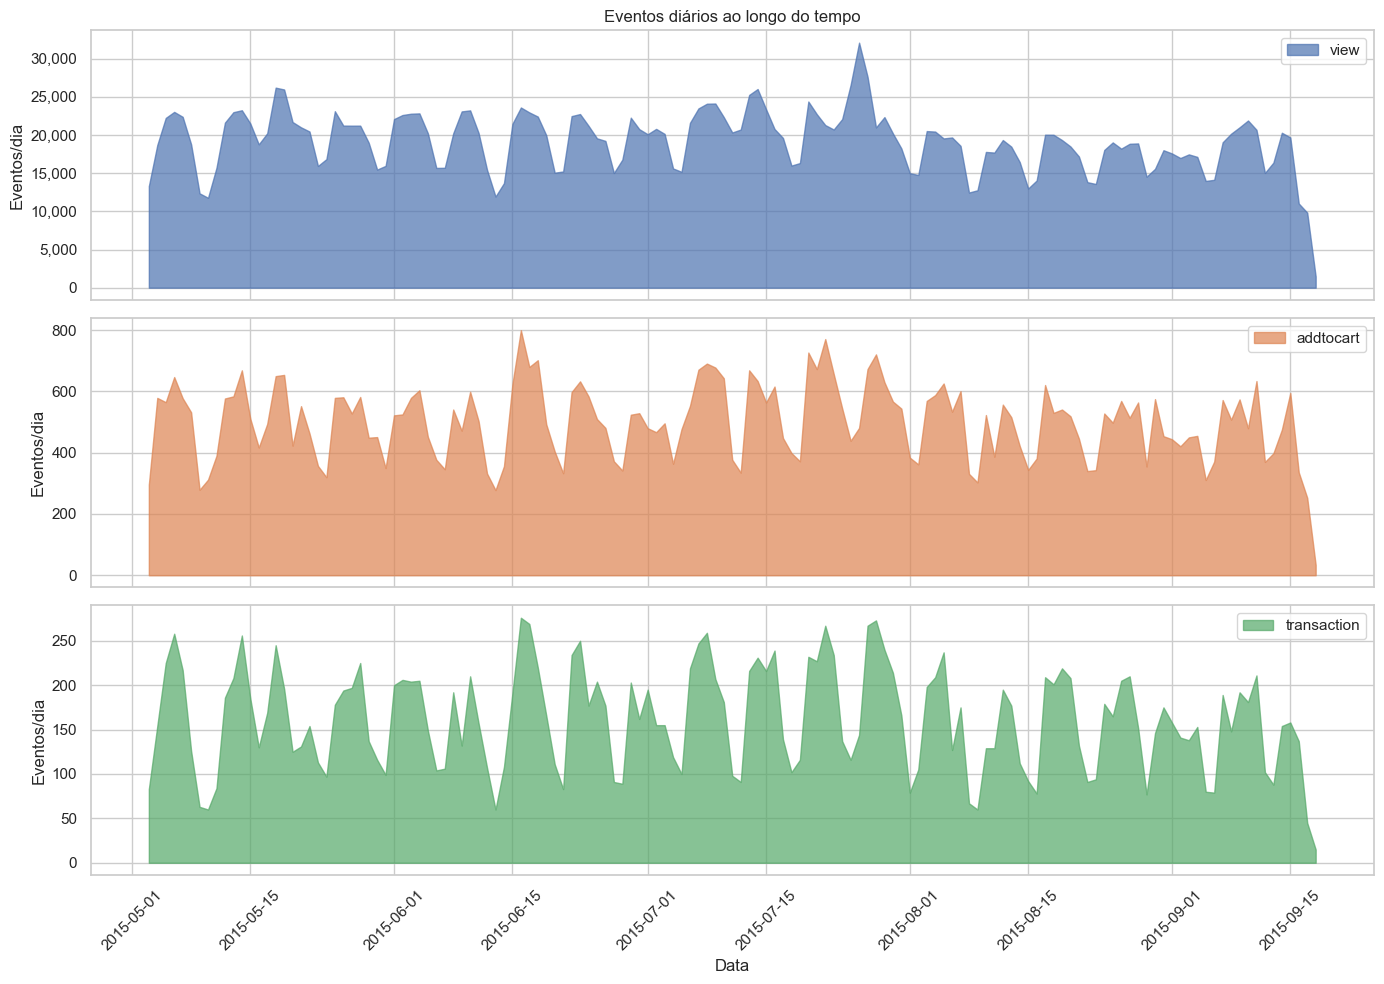

In [25]:
events["date"] = events["timestamp"].dt.date
daily = events.groupby(["date", "event"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
event_colors = {"view": "#4C72B0", "addtocart": "#DD8452", "transaction": "#55A868"}

for ax, ev in zip(axes, ["view", "addtocart", "transaction"]):
    if ev in daily.columns:
        ax.fill_between(
            daily.index, daily[ev], alpha=0.7, color=event_colors[ev], label=ev
        )
        ax.set_ylabel("Eventos/dia")
        ax.legend(loc="upper right")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[0].set_title("Eventos diários ao longo do tempo")
plt.xlabel("Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

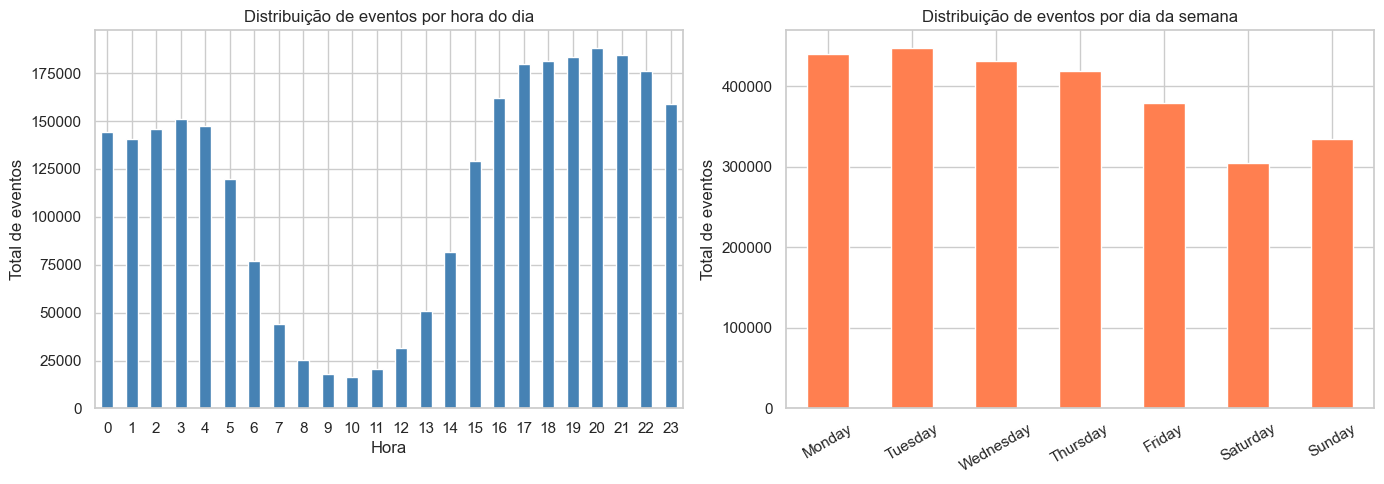

In [26]:
events["hour"] = events["timestamp"].dt.hour
events["dayofweek"] = events["timestamp"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = events.groupby("hour").size()
hourly.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição de eventos por hora do dia")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Total de eventos")
axes[0].tick_params(axis="x", rotation=0)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
daily_dow = events.groupby("dayofweek").size().reindex(day_order)
daily_dow.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Distribuição de eventos por dia da semana")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total de eventos")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 3. Item Properties

In [13]:
props.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [14]:
props.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 618.8+ MB


In [15]:
print("Nulos por coluna:")
print(props.isnull().sum())
print(f"\nItens únicos com propriedades: {props.itemid.nunique():,}")
print(f"Propriedades distintas:        {props.property.nunique():,}")

Nulos por coluna:
timestamp    0
itemid       0
property     0
value        0
dtype: int64

Itens únicos com propriedades: 417,053
Propriedades distintas:        1,104


In [16]:
props["timestamp"] = pd.to_datetime(props["timestamp"], unit="ms")
print("Período coberto (props):")
print(f"  Início: {props.timestamp.min()}")
print(f"  Fim:    {props.timestamp.max()}")

Período coberto (props):
  Início: 2015-05-10 03:00:00
  Fim:    2015-09-13 03:00:00


### 3.1 Propriedades mais comuns

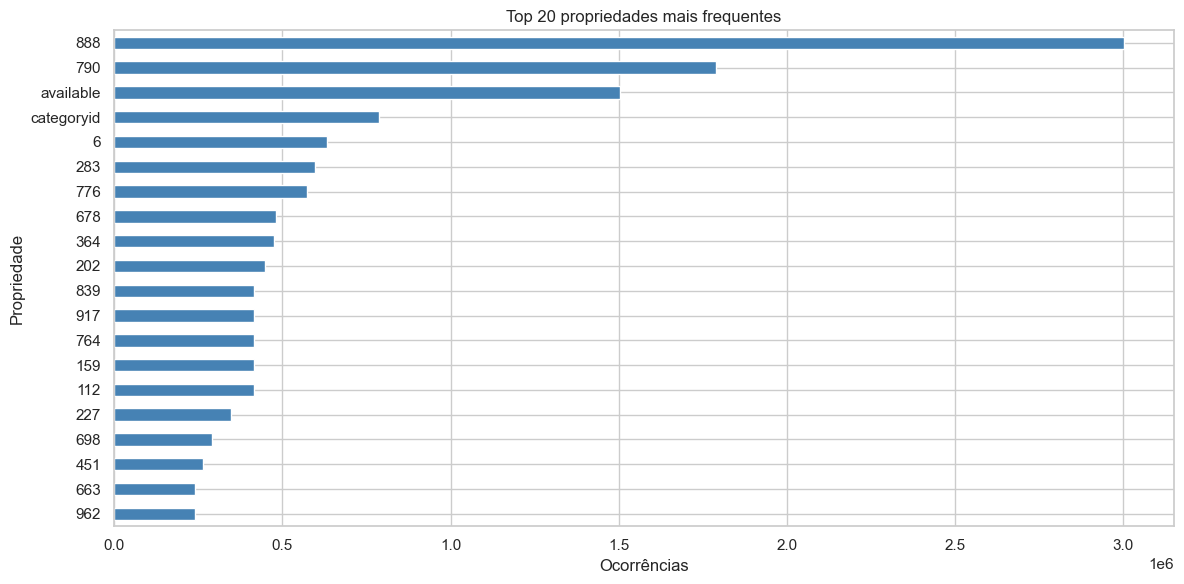


Top 20:
property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
764            417053
159            417053
112            417053
227            347492
698            289849
451            264416
663            240813
962            239372


In [17]:
top_props = props["property"].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_props.plot(kind="barh", color="steelblue")
plt.title("Top 20 propriedades mais frequentes")
plt.xlabel("Ocorrências")
plt.ylabel("Propriedade")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20:")
print(top_props.to_string())

### 3.2 Quantidade de propriedades por item

Propriedades únicas por item:
count    417053.00
mean         28.78
std           7.41
min          12.00
25%          24.00
50%          27.00
75%          31.00
max          59.00
Name: property, dtype: object


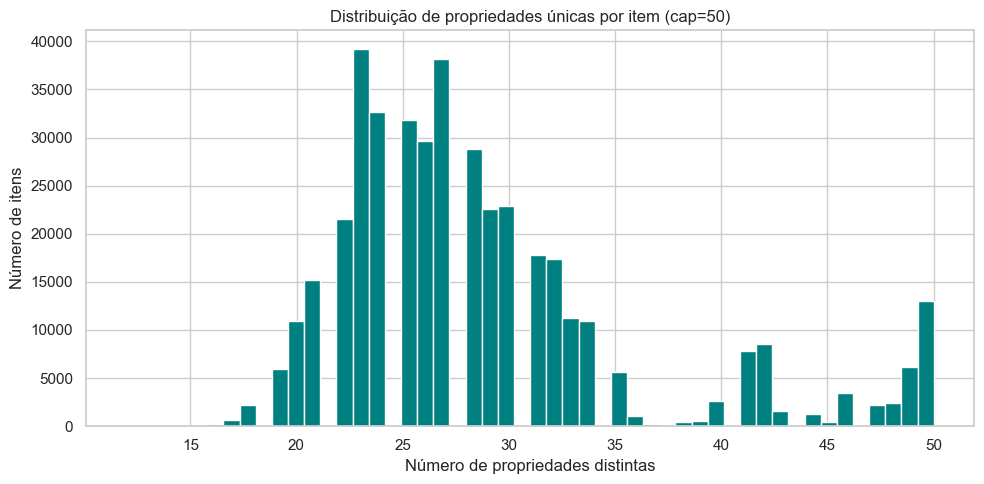

In [18]:
props_per_item = props.groupby("itemid")["property"].nunique()

print("Propriedades únicas por item:")
print(props_per_item.describe().apply(lambda x: f"{x:.2f}"))

plt.figure(figsize=(10, 5))
props_per_item.clip(upper=50).hist(bins=50, color="teal", edgecolor="white")
plt.title("Distribuição de propriedades únicas por item (cap=50)")
plt.xlabel("Número de propriedades distintas")
plt.ylabel("Número de itens")
plt.tight_layout()
plt.show()

### 3.3 Disponibilidade dos itens (propriedade `available`)

Valores de disponibilidade:
value
0    863086
1    640553
Name: count, dtype: int64


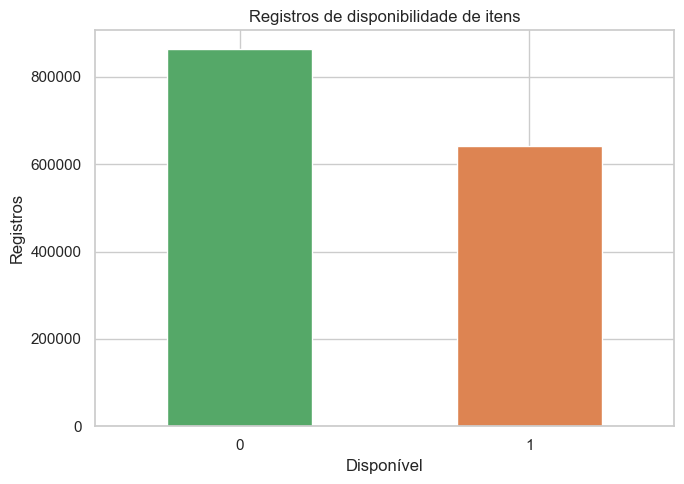

In [19]:
avail = props[props["property"] == "available"].copy()

if len(avail) > 0:
    avail_counts = avail["value"].value_counts()
    print("Valores de disponibilidade:")
    print(avail_counts)

    plt.figure(figsize=(7, 5))
    avail_counts.plot(kind="bar", color=["#55A868", "#DD8452"])
    plt.title("Registros de disponibilidade de itens")
    plt.xlabel("Disponível")
    plt.ylabel("Registros")
    plt.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Propriedade "available" não encontrada.')

---
## 4. Category Tree

In [20]:
cat_tree.head(10)

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0
7,1146,542.0
8,1140,542.0
9,1479,1537.0


In [21]:
cat_tree.info()
print(f"\nNulos: {cat_tree.isnull().sum().to_dict()}")
print(f"Categorias totais: {cat_tree.categoryid.nunique():,}")
print(f"Categorias raiz (sem pai): {cat_tree.parentid.isnull().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB

Nulos: {'categoryid': 0, 'parentid': 25}
Categorias totais: 1,669
Categorias raiz (sem pai): 25


### 4.1 Profundidade da árvore de categorias

Categorias por nível de profundidade:
depth
0     25
1    174
2    702
3    665
4     90
5     13


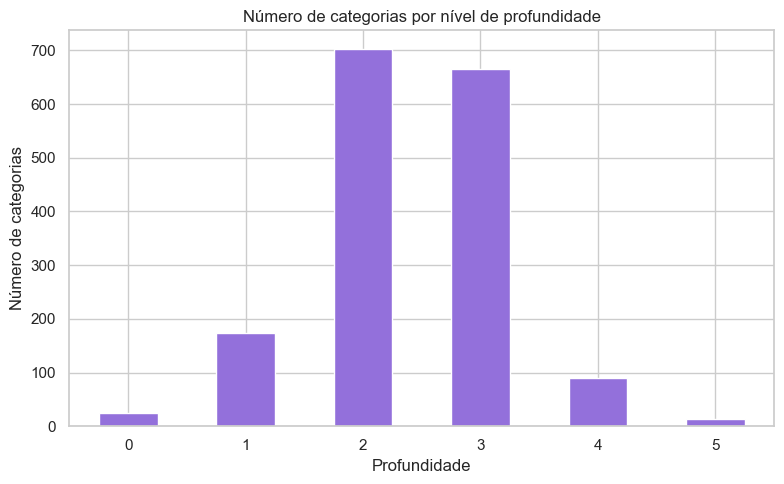

In [22]:
parent_map = dict(zip(cat_tree["categoryid"], cat_tree["parentid"]))


def get_depth(cat_id, memo={}):
    if cat_id in memo:
        return memo[cat_id]
    parent = parent_map.get(cat_id)
    if pd.isna(parent) or parent not in parent_map:
        memo[cat_id] = 0
    else:
        memo[cat_id] = 1 + get_depth(parent, memo)
    return memo[cat_id]


cat_tree["depth"] = cat_tree["categoryid"].apply(get_depth)

depth_counts = cat_tree["depth"].value_counts().sort_index()
print("Categorias por nível de profundidade:")
print(depth_counts.to_string())

plt.figure(figsize=(8, 5))
depth_counts.plot(kind="bar", color="mediumpurple", edgecolor="white")
plt.title("Número de categorias por nível de profundidade")
plt.xlabel("Profundidade")
plt.ylabel("Número de categorias")
plt.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Categorias com mais filhos diretos

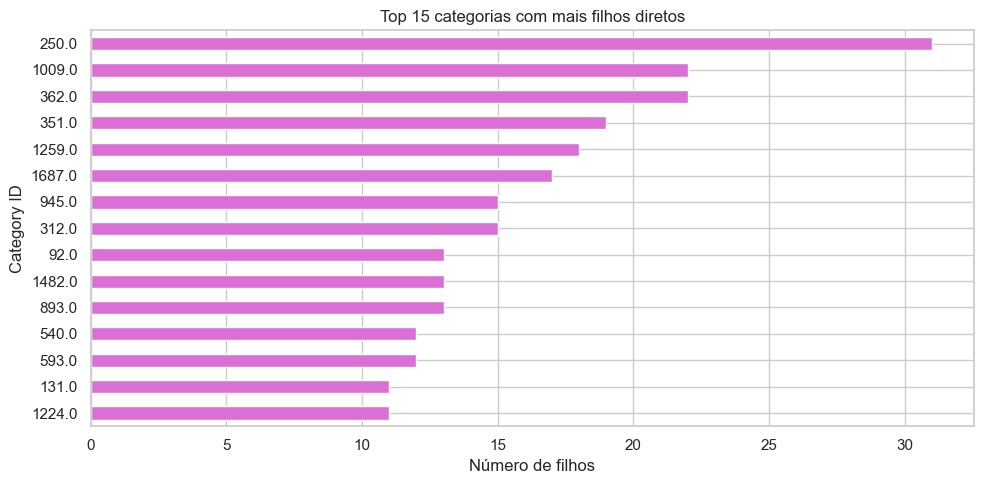

In [23]:
children_per_parent = (
    cat_tree.dropna(subset=["parentid"])["parentid"].value_counts().head(15)
)

plt.figure(figsize=(10, 5))
children_per_parent.plot(kind="barh", color="orchid")
plt.title("Top 15 categorias com mais filhos diretos")
plt.xlabel("Número de filhos")
plt.ylabel("Category ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Análise Cruzada

### 5.1 Cobertura: itens com eventos vs itens com propriedades

Itens somente em events:     49,815
Itens somente em properties: 231,807
Itens em ambos:              185,246


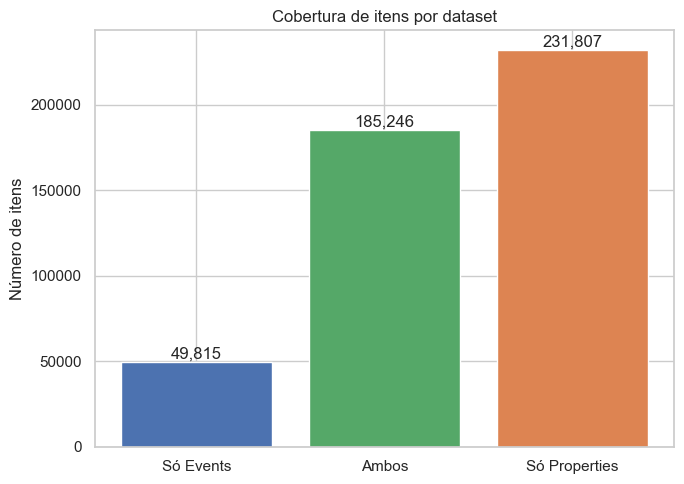

In [24]:
items_in_events = set(events["itemid"].unique())
items_in_props = set(props["itemid"].unique())

only_events = items_in_events - items_in_props
only_props = items_in_props - items_in_events
both = items_in_events & items_in_props

print(f"Itens somente em events:     {len(only_events):,}")
print(f"Itens somente em properties: {len(only_props):,}")
print(f"Itens em ambos:              {len(both):,}")

try:
    from matplotlib_venn import venn2

    plt.figure(figsize=(7, 5))
    venn2([items_in_events, items_in_props], set_labels=("Events", "Properties"))
    plt.title("Sobreposição de itens entre eventos e propriedades")
    plt.tight_layout()
    plt.show()
except ImportError:
    labels = ["Só Events", "Ambos", "Só Properties"]
    sizes = [len(only_events), len(both), len(only_props)]
    plt.figure(figsize=(7, 5))
    plt.bar(labels, sizes, color=["#4C72B0", "#55A868", "#DD8452"])
    plt.title("Cobertura de itens por dataset")
    plt.ylabel("Número de itens")
    for i, v in enumerate(sizes):
        plt.text(i, v + 100, f"{v:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

### 5.2 Categorias dos itens comprados

Itens comprados com categoria mapeada: 11,645 / 12,025


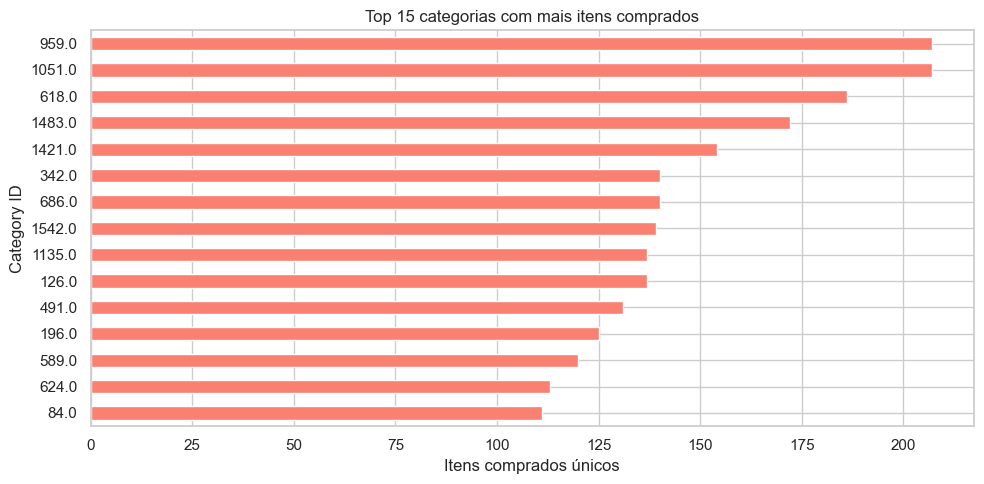

In [25]:
purchased_items = events[events["event"] == "transaction"]["itemid"].unique()

item_categories = (
    props[props["property"] == "categoryid"]
    .sort_values("timestamp")
    .groupby("itemid")["value"]
    .last()
    .reset_index()
    .rename(columns={"value": "categoryid"})
)
item_categories["categoryid"] = pd.to_numeric(
    item_categories["categoryid"], errors="coerce"
)

purchased_df = pd.DataFrame({"itemid": purchased_items})
purchased_df = purchased_df.merge(item_categories, on="itemid", how="left")

top_cats = purchased_df["categoryid"].value_counts().head(15)

print(
    f"Itens comprados com categoria mapeada: {purchased_df.categoryid.notna().sum():,} / {len(purchased_df):,}"
)

plt.figure(figsize=(10, 5))
top_cats.plot(kind="barh", color="salmon")
plt.title("Top 15 categorias com mais itens comprados")
plt.xlabel("Itens comprados únicos")
plt.ylabel("Category ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3 Taxa de conversão por item (views → transactions)

Itens com >= 10 views: 54,132
Taxa de conversão (views >= 10):
count    54132.0000
mean         0.0083
std          0.0227
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.5000
Name: conversion, dtype: object


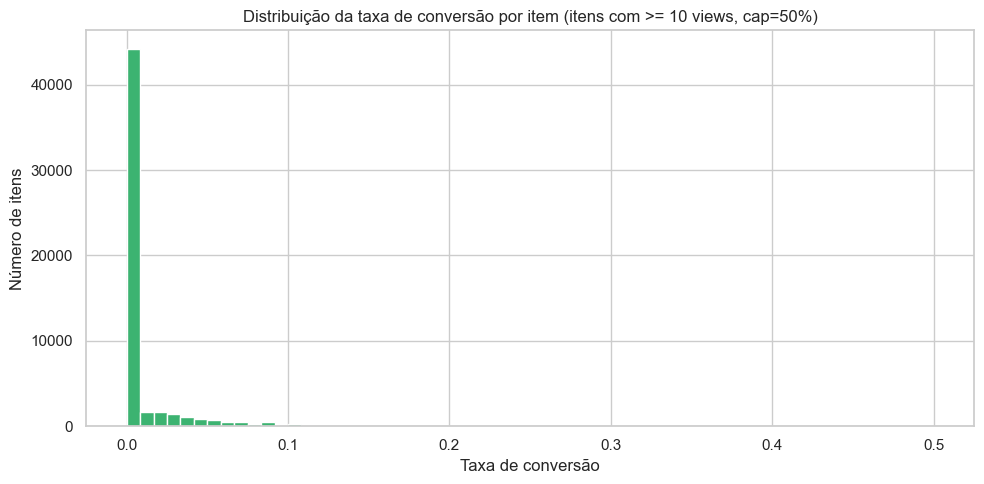

In [26]:
views_per_item = events[events.event == "view"].groupby("itemid").size().rename("views")
buys_per_item = (
    events[events.event == "transaction"].groupby("itemid").size().rename("buys")
)

item_funnel = pd.concat([views_per_item, buys_per_item], axis=1).fillna(0)
item_funnel["conversion"] = item_funnel["buys"] / item_funnel["views"]

item_funnel_filtered = item_funnel[item_funnel["views"] >= 10]

print(f"Itens com >= 10 views: {len(item_funnel_filtered):,}")
print("Taxa de conversão (views >= 10):")
print(item_funnel_filtered["conversion"].describe().apply(lambda x: f"{x:.4f}"))

plt.figure(figsize=(10, 5))
item_funnel_filtered["conversion"].clip(upper=0.5).hist(
    bins=60, color="mediumseagreen", edgecolor="white"
)
plt.title("Distribuição da taxa de conversão por item (itens com >= 10 views, cap=50%)")
plt.xlabel("Taxa de conversão")
plt.ylabel("Número de itens")
plt.tight_layout()
plt.show()

---
## 6. Sumário

In [27]:
print("=== SUMÁRIO DO DATASET ===")
print(
    f"Período:              {events.timestamp.min().date()} → {events.timestamp.max().date()}"
)
print()
print("--- Events ---")
print(f"Total de eventos:     {len(events):,}")
print(f"Visitantes únicos:    {events.visitorid.nunique():,}")
print(f"Itens únicos:         {events.itemid.nunique():,}")
print(f"Views:                {event_counts.get('view', 0):,}")
print(f"Add-to-cart:          {event_counts.get('addtocart', 0):,}")
print(f"Transactions:         {event_counts.get('transaction', 0):,}")
print(f"Conv. view→buy:       {view_to_purchase:.3f}%")
print()
print("--- Item Properties ---")
print(f"Registros:            {len(props):,}")
print(f"Itens únicos:         {props.itemid.nunique():,}")
print(f"Propriedades únicas:  {props.property.nunique():,}")
print()
print("--- Category Tree ---")
print(f"Categorias:           {cat_tree.categoryid.nunique():,}")
print(f"Categorias raiz:      {cat_tree.parentid.isnull().sum():,}")
print(f"Profundidade máxima:  {cat_tree.depth.max()}")

=== SUMÁRIO DO DATASET ===
Período:              2015-05-03 → 2015-09-18

--- Events ---
Total de eventos:     2,756,101
Visitantes únicos:    1,407,580
Itens únicos:         235,061
Views:                2,664,312
Add-to-cart:          69,332
Transactions:         22,457
Conv. view→buy:       0.843%

--- Item Properties ---
Registros:            20,275,902
Itens únicos:         417,053
Propriedades únicas:  1,104

--- Category Tree ---
Categorias:           1,669
Categorias raiz:      25
Profundidade máxima:  5
